# IMPORTS

In [5]:
from qiskit import *
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_state_city
import qiskit.quantum_info as qi
from qiskit.visualization import plot_histogram
from math import gcd
from numpy.random import randint
import pandas as pd
from fractions import Fraction
from tqdm import tqdm
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
import matplotlib.pyplot as plt
import random
import sys
import math
import array
import fractions
import numpy as np

# PART 1 : GENERAL IMPLEMENTATION , 

## How to do the U operation
- this follows implementation of https://arxiv.org/pdf/quant-ph/0205095
- randomly select a number from those co - primes (for a large N and perform the U operations for that number (have to be hard-coded as of 19-12-24)
- can try an approach where we just choose a = 2^j for successive j's as all are def. co prime for given N and those U's can be hardcoded easily
- wont work well though , as each 2^j has P(failure)<= 0.5 , and successive 2^j's will give back the same period
- as you can see , this issue of implementing U (modular exponentiation) gate is the bottleneck of shor's algorithm
- Classically , modular exponentiation is implemented v easily and efficiently , but doing so using qubits/gates is much more difficult
- As of now , there exists no method to implement it which isnt resulting in exponential worse case time complexity
- Neverthless , we present a way to run Shor's algorithm in a much more general fashion

## QFT and QFT$^{-1}$
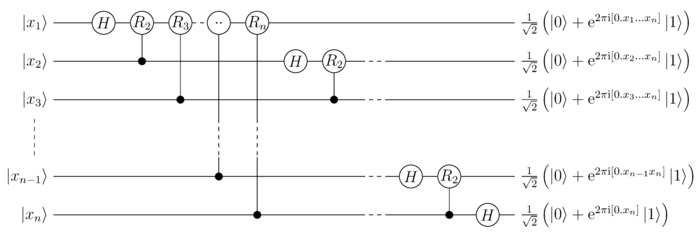

In [3]:
''' Function to create QFT for a given circuit and its up_reg (num = n) , also has a 
swap-condition to increase functionality ,
doing the swaps (optional because in places like mod multiplication the goal
isnt to get QFT but to rather add/multiply for which swap is unnecessary so it jus
contributes to inreasing gate count ''' 
def create_QFT(circuit , up_reg , n , with_swap):
    i = n-1
    # pre swap , we do the operations
    while i >= 0:
        circuit.h(up_reg[i])
        j = i-1
        # now we apply the controlled phase gates R_k
        while j>=0:
            # applying phase gate to up_reg[j], controlled by up_reg[i]
            if (np.pi)/(pow(2,(i-j))) > 0 :
                circuit.cp((np.pi)/(pow(2,(i-j))) , up_reg[i] , up_reg[j])
            j-=1
        i-=1
    # this is the end of the qft thing usually (with_swap = 0 usually)
    if with_swap == 1:
            i = 0
            while i < (n-1)/2:
                circuit.swap(up_reg[i] , up_reg[n-i-1])
                i+=1

def create_inverse_QFT(circuit,up_reg,n,with_swaps):
    # If specified, apply the Swaps at the beggining
    if with_swaps==1:
        i=0
        while i < ((n-1)/2):
            circuit.swap(up_reg[i], up_reg[n-1-i])
            i=i+1
    
    # just reversing the operations in QFT
    i=0
    while i<n:
        circuit.h(up_reg[i])
        if i != n-1:
            j=i+1
            y=i
            while y>=0:
                 if (np.pi)/(pow(2,(j-y))) > 0:
                    circuit.cp( - (np.pi)/(pow(2,(j-y))) , up_reg[j] , up_reg[y] )
                    y=y-1   
        i=i+1

# MODULAR MULTIPLICATION

## Helper functions

In [7]:
def c_cphase(circuit , angle , ctl1 , ctl2 , tgt):
    # applies doubly controlled phase gate
    circuit.cp(angle/2 , ctl1 , tgt)
    circuit.cx(ctl2,ctl1)
    circuit.cp(-angle/2 , ctl1 , tgt)
    circuit.cx(ctl2,ctl1)
    circuit.cp(angle/2 , ctl2 , tgt)
"""Function that calculates the array of angles to be used in the addition in Fourier Space"""
def getAngles(a,N): # note : N here is just the no. of qubits for adding a , not the N = pq
    s=bin(int(a))[2:].zfill(N) 
    angles=np.zeros([N])
    for i in range(0, N):
        for j in range(i,N):
            if s[j]=='1':
                angles[N-i-1]+=math.pow(2, -(j-i))
        angles[N-i-1]*=np.pi
    return angles

''' ckt to perform add by a in the fourier space
equivalent to subtracter if inv is set to !0 
q is array of qubits in the ckt '''
def phi_add(circuit , q , a , n , inv ): # n here is number of qubits more or less
    angle = getAngles(a,n)
    for i in range(n):
        if inv == 0:
            circuit.p(angle[i],q[i])
        else:
            circuit.p(-angle[i],q[i])
            
"""Single controlled version of the phiADD circuit"""
def cphiADD(circuit,q,ctl,a,n,inv): # n here is number of qubits
    angle=getAngles(a,n)
    for i in range(0,n):
        if inv==0:
            circuit.cp(angle[i],ctl,q[i])
        else:
            circuit.cp(-angle[i],ctl,q[i])
            
    
# doubly controlled addition by a in the fourier space
def c_cphiadd(circuit,q,ctl1,ctl2,a,N,inv):
    angle = getAngles(a,N)
    for i in range(N):
        if inv == 0:
            c_cphase(circuit , angle[i] , ctl1,ctl2,q[i])
        else:
            c_cphase(circuit , -angle[i] , ctl1,ctl2,q[i])
            
def egcd(a, b):
    if a == 0:
        return (b, 0, 1)
    else:
        g, y, x = egcd(b % a, a)
        return (g, x - (b // a) * y, y)


def modinv(a, m):
    g, x, y = egcd(a, m)
    if g != 1:
        raise Exception('modular inverse does not exist')
    else:
        return x % m

def get_coprime(N):
    return random.randint(2,N-2)

## Modular addition + it's inverse : doubly controlled

In [8]:
# doing doubly modular addition by a (mod N)
def c_cphiadd_modN(circuit , q, ctl1, ctl2 , aux , a, N,n):
    c_cphiadd(circuit,q,ctl1,ctl2,a,n,0) # add a
    phi_add(circuit,q,N,n,1) # subtract N
    create_inverse_QFT(circuit,q,n,0) # inv Qft to check msb for doing modular addn
    circuit.cx(q[n-1],aux) # checking if addition by a exceeds N
    create_QFT(circuit , q , n , 0) # recreating qft after check
    cphiADD(circuit,q,aux,N,n,0) # adding N back if a's addition didnt exceed N


    c_cphiadd(circuit,q,ctl1,ctl2,a,n,1) # subtracting a
    create_inverse_QFT(circuit,q,n,0) 
    circuit.x(q[n-1])
    circuit.cx(q[n-1],aux)
    circuit.x(q[n-1])
    create_QFT(circuit , q , n , 0) # recreating qft after check
    c_cphiadd(circuit,q,ctl1,ctl2,a,n,0)

# ckt to implement inv of doubly controlled modular addition (reverse each gate and order)
def c_cphiadd_modN_inv(circuit, q, ctl1, ctl2, aux, a, N, n):
    c_cphiadd(circuit, q, ctl1, ctl2, a, n, 1)
    create_inverse_QFT(circuit, q, n, 0)
    circuit.x(q[n-1])
    circuit.cx(q[n-1],aux)
    circuit.x(q[n-1])
    create_QFT(circuit, q, n, 0)
    c_cphiadd(circuit, q, ctl1, ctl2, a, n, 0)
    cphiADD(circuit, q, aux, N, n, 1)
    create_inverse_QFT(circuit, q, n, 0)
    circuit.cx(q[n-1], aux)
    create_QFT(circuit, q, n, 0)
    phi_add(circuit, q, N, n, 0)
    c_cphiadd(circuit, q, ctl1, ctl2, a, n, 1)

## Modular multiplication

In [9]:
def c_mult_modN(circuit,ctl1,q,aux,a,N,n): # controlled mult. by a (mod N)
    # aux is an array of n+1 qubits set to |0>
    create_QFT(circuit,aux,n+1,0)
    for i in range(n):
        c_cphiadd_modN(circuit,aux,q[i],ctl1,aux[n+1],(2**i)*a%N,N,n+1)
    create_inverse_QFT(circuit, aux, n+1, 0)
    for i in range(0,n): # swap contents 
        circuit.cswap(ctl1,q[i],aux[i])
    a_inv = modinv(a,N)
    # now multilpying contents of 2nd reg ( now in state |q> ) with a-1 mod N * aqmodN essentially
    create_QFT(circuit,aux,n+1,0)
    for i in range(n-1,-1,-1):
        c_cphiadd_modN_inv(circuit,aux,q[i],ctl1,aux[n+1],math.pow(2,i)*a_inv%N,N,n+1)
    create_inverse_QFT(circuit, aux, n+1, 0)
    


## Final Circuit

In [14]:
# this output is essentially (s/r)/2*t (t = 2n) - s is the random eigenvector number we got
# as our input is |1> = sum of all eigenstates from s = 0 to r-1
#converting to s/r
def get_answer(counts,N,n):
 t = 2*n
    # this output is essentially (s/r)/2*t (t = 2n) - s is the random eigenvector number we got
# as our input is |1> = sum of all eigenstates from s = 0 to r-1
#converting to s/r
 rows, measured_phases = [], []
 for output in counts:
    decimal = int(output, 2)  # Convert (base 2) string to decimal
    phase = decimal/(2**t)  # Find corresponding eigenvalue
    measured_phases.append(phase)
    # Add these values to the rows in our table:
    rows.append([f"{output}(bin) = {decimal:>3}(dec)",
                 f"{decimal}/{2**t} = {phase:.2f}"])
# Print the rows in a table
 headers=["Register Output", "Phase"]
 df = pd.DataFrame(rows, columns=headers)
 print(df)
 # continued fractions to determine r
 rows = []
 for phase in measured_phases:
    frac = Fraction(phase).limit_denominator(N) #gets the c.f expansion
    rows.append([phase,
                 f"{frac.numerator}/{frac.denominator}",
                 frac.denominator])
#print
 headers=["Phase", "Fraction", "Guess for r"]
 df = pd.DataFrame(rows,columns = headers)
 print(df) 
 return frac.denominator   
    
    
def Shors_Algorithm(N,a):
    n = math.ceil(math.log(N,2)) # number of bits for N
    # this algo uses 4n+2 qubits
    aux  = QuantumRegister(n+2) # aux for addn / multiplication (mod N)
    up_reg = QuantumRegister(2*n) # for QFT ( t = 2n qubits )
    down_reg = QuantumRegister(n) # register where mod multiplication is applied
    up_classic = ClassicalRegister(2*n) # for storing results

    """ Create Quantum Circuit """
    circuit = QuantumCircuit(down_reg , up_reg , aux, up_classic)

    # create superposn + |1> state in down registers
    circuit.h(up_reg)
    circuit.x(down_reg[0])

    for i in range(2*n):
        c_mult_modN(circuit,up_reg[i],down_reg,aux,int(pow(a,pow(2,i))),N,n) # controlled mult. by a^(2^i) (mod N)


    # applying QFT_inv
    create_inverse_QFT(circuit,up_reg,2*n,1)
    
    # measure top qubits
    circuit.measure(up_reg,up_classic)

    #return circuit
    return circuit



In [ ]:
''' main program '''
N = 21 #int(input("Enter number to factorize : "))
a = 2
gcd = math.gcd(a,N)
if gcd!= 1:
    print("Factors are : " , gcd , N/gcd)
else:
    circuit = Shors_Algorithm(N,a)
    aer_sim = AerSimulator()
    t_qc = transpile(circuit, aer_sim)
    counts = aer_sim.run(t_qc,shots = 1).result().get_counts()
    r_guess = get_answer(counts,N,math.ceil(math.log(N, 2)))
    if r_guess%2==0:
        period = int(r_guess / 2)
        print("FACTORS CANDIDATES ARE : ",math.gcd(N, (a ** period - 1)),math.gcd(N, (a ** period + 1)))
    else:
        
        print("trying 2r")
        res = (a**(r_guess*2)) % N  
        if res == 1:
            period = int(r_guess)
            print("FACTORS CANDIDATES ARE : ",math.gcd(N, (a ** period - 1)),math.gcd(N, (a ** period + 1)))
                
        else :
            print("found period isn't divisible by 2, try again")
            
    
    

# PART 2 : Hand-crafting Unitaries for Modular Multiplication (fixed N and/or A)

- for N = 15 , we handcraft a Unitary which works for all a
- for N = 143 , we handcraft a Unitary specific to a = 21
- Ofcourse, doing such automatically reveals the period of the N we took , neverthless, these are toy/dummy implementations to show that Shor's Algorithm Correctness

In [6]:
def c_amod15(a,power): # a represents the co-prime number to N(=15) 
    if a not in [2,4,7,8,11,13]:
        print("a isnt co prime to 15")
    U = QuantumCircuit(4) #bottom log(15) qubits
    # performing U operations based of input = a ( v specific to N = 15 's case here )
    for it in range(power):
        if a in [2,13]:
            U.swap(2,3)
            U.swap(1,2)
            U.swap(0,1)
        if a in [7,8]:
            U.swap(0,1)
            U.swap(1,2)
            U.swap(2,3)
        if a in [4, 11]:
            U.swap(1,3)
            U.swap(0,2)
            
        if a in [7,11,13]:
            for q in range(4):
                U.x(q)
    # conv U to a gate on 4 qubits
    U = U.to_gate()
    U.name = f"{a}^{power} mod 15"
    c_U = U.control() # making a control version of the gate
    return c_U


def c_21mod143(power, show_progress=False):
    U = QuantumCircuit(7)

    iterator = range(power)
    if show_progress:
        iterator = tqdm(iterator, desc=f"Power={power}", leave=False)

    for it in iterator:
        U.cx(0,4)
        U.cx(0,2)
        U.x(4)
        U.cx(4,0)
        U.cx(4,2)
        U.cx(4,3)
        U.ccx(0,4,2)
        U.ccx(0,4,3)
        U.x(2)
        U.ccx(0,4,5)
        U.ccx(0,4,6)
        U.x(4)
        U.ccx(3,4,5)
        U.ccx(3,4,6)
        U.ccx(0,2,3)
        U.ccx(0,2,4)
        U.x(2)

    U = U.to_gate()
    U.name = f"21^{power} mod 143"
    return U.control()

## The QFT$^{-1}$ ckt

In [37]:
def qft_dagger(n): # n-qubit QFT inv operation
    qc = QuantumCircuit(n)
    # creating the ciruit using swaps and controlled phase gates
    for qubit in range(n//2):
        qc.swap(qubit, n-qubit-1)
    for j in range(n):
        for m in range(j):
            qc.cp(-np.pi/float(2**(j-m)), m, j)
        qc.h(j)
    QFT_inv = qc.to_gate()
    QFT_inv.name = "QFT†"
    return QFT_inv

## Running the circuit for N = 15 , we take t = 8 
- Note that we can afford to have 128 runs of the circuit here, for N = 143 , we can only do 1 shot in a feasible amount of time

In [38]:
t = 8
a = 2
qc = QuantumCircuit(t + 4 , t) # log(15) = 4 and need t classical bits to store the info
# superimposing all initial t qbits
for q in range(t):
    qc.h(q)
# rest 4 combined in state |00001>
qc.x(t)
# doing controlled-U operations
# here , the 1st bit supplied (q) is the control bit for the c_U operation returned
# by the function
for q in range(t):
    qc.append(c_amod15(a,2**q),[q] + [t,t+1,t+2,t+3])

# applying Qft_inv
qc.append(qft_dagger(t),range(t))

# measure ckt - t qubits measure , store in t classical ones
qc.measure(range(t),range(t))
qc.draw(fold = -1) # draw ckt (fold = 1 makes it more like vertical)



┌───┐                                                                                                                             ┌───────┐┌─┐                     
 q_0: ┤ H ├───────■─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤0      ├┤M├─────────────────────
      ├───┤       │                                                                                                                     │       │└╥┘┌─┐                  
 q_1: ┤ H ├───────┼──────────────■──────────────────────────────────────────────────────────────────────────────────────────────────────┤1      ├─╫─┤M├──────────────────
      ├───┤       │              │                                                                                                      │       │ ║ └╥┘┌─┐               
 q_2: ┤ H ├───────┼──────────────┼──────────────■───────────────────────────────────────────────────────────────────────────────────────┤2      ├─╫──╫─┤M├───────────────
      ├───┤       │              │              │                                                                                       │       │ ║  ║ └╥┘┌─┐            
 q_3: ┤ H ├───────┼──────────────┼──────────────┼──────────────■────────────────────────────────────────────────────────────────────────┤3      ├─╫──╫──╫─┤M├────────────
      ├───┤       │              │              │              │                                                                        │  QFT† │ ║  ║  ║ └╥┘┌─┐         
 q_4: ┤ H ├───────┼──────────────┼──────────────┼──────────────┼──────────────■─────────────────────────────────────────────────────────┤4      ├─╫──╫──╫──╫─┤M├─────────
      ├───┤       │              │              │              │              │                                                         │       │ ║  ║  ║  ║ └╥┘┌─┐      
 q_5: ┤ H ├───────┼──────────────┼──────────────┼──────────────┼──────────────┼───────────────■─────────────────────────────────────────┤5      ├─╫──╫──╫──╫──╫─┤M├──────
      ├───┤       │              │              │              │              │               │                                         │       │ ║  ║  ║  ║  ║ └╥┘┌─┐   
 q_6: ┤ H ├───────┼──────────────┼──────────────┼──────────────┼──────────────┼───────────────┼───────────────■─────────────────────────┤6      ├─╫──╫──╫──╫──╫──╫─┤M├───
      ├───┤       │              │              │              │              │               │               │                         │       │ ║  ║  ║  ║  ║  ║ └╥┘┌─┐
 q_7: ┤ H ├───────┼──────────────┼──────────────┼──────────────┼──────────────┼───────────────┼───────────────┼────────────────■────────┤7      ├─╫──╫──╫──╫──╫──╫──╫─┤M├
      ├───┤┌──────┴──────┐┌──────┴──────┐┌──────┴──────┐┌──────┴──────┐┌──────┴───────┐┌──────┴───────┐┌──────┴───────┐┌───────┴───────┐└───────┘ ║  ║  ║  ║  ║  ║  ║ └╥┘
 q_8: ┤ X ├┤0            ├┤0            ├┤0            ├┤0            ├┤0             ├┤0             ├┤0             ├┤0              ├──────────╫──╫──╫──╫──╫──╫──╫──╫─
      └───┘│             ││             ││             ││             ││              ││              ││              ││               │          ║  ║  ║  ║  ║  ║  ║  ║ 
 q_9: ─────┤1            ├┤1            ├┤1            ├┤1            ├┤1             ├┤1             ├┤1             ├┤1              ├──────────╫──╫──╫──╫──╫──╫──╫──╫─
           │  2^1 mod 15 ││  2^2 mod 15 ││  2^4 mod 15 ││  2^8 mod 15 ││  2^16 mod 15 ││  2^32 mod 15 ││  2^64 mod 15 ││  2^128 mod 15 │          ║  ║  ║  ║  ║  ║  ║  ║ 
q_10: ─────┤2            ├┤2            ├┤2            ├┤2            ├┤2             ├┤2             ├┤2             ├┤2              ├──────────╫──╫──╫──╫──╫──╫──╫──╫─
           │             ││             ││             ││             ││              ││              ││              ││               │          ║  ║  ║  ║  ║  ║  ║  ║ 
q_11: ─────┤3            ├┤3            ├┤3            ├┤3            ├┤3             ├┤3       

In [39]:
print("Depth:", qc.depth())
print("Gate count:", qc.size())

Depth: 11
Gate count: 26


In [40]:
aer_sim = AerSimulator()
start = time.time()
t_qc = transpile(qc, aer_sim, optimization_level=0)
print(f"Transpile time: {time.time() - start:.2f}s")
start = time.time()
job = aer_sim.run(t_qc, shots = 128)
result = job.result()
print(f"Run time: {time.time() - start:.2f}s")
start = time.time()
counts = result.get_counts()
print(f"Post-processing time: {time.time() - start:.2f}s")
plot_histogram(counts)

# this output is essentially (s/r)/2*t (t = 2n) - s is the random eigenvector number we got
# as our input is |1> = sum of all eigenstates from s = 0 to r-1
#converting to s/r
rows, measured_phases = [], []
for output in counts:
    decimal = int(output, 2)  # Convert (base 2) string to decimal
    phase = decimal/(2**t)  # Find corresponding eigenvalue
    measured_phases.append(phase)
    # Add these values to the rows in our table:
    rows.append([f"{output}(bin) = {decimal:>3}(dec)",
                 f"{decimal}/{2**t} = {phase:.2f}"])
# Print the rows in a table
headers=["Register Output", "Phase"]
df = pd.DataFrame(rows, columns=headers)
print(df)

Transpile time: 0.11s
Run time: 0.06s
Post-processing time: 0.00s
            Register Output           Phase
0  10000000(bin) = 128(dec)  128/256 = 0.50
1  11000000(bin) = 192(dec)  192/256 = 0.75
2  00000000(bin) =   0(dec)    0/256 = 0.00
3  01000000(bin) =  64(dec)   64/256 = 0.25


In [41]:
# continued fractions to determine r
rows = []
for phase in measured_phases:
    frac = Fraction(phase).limit_denominator(15) #gets the c.f expansion
    rows.append([phase,
                 f"{frac.numerator}/{frac.denominator}",
                 frac.denominator])
#print
headers=["Phase", "Fraction", "Guess for r"]
df = pd.DataFrame(rows,columns = headers)
print(df)
N = 15
a = 2
for entry in rows:
    r = entry[2] #our guess
    if r%2!=0:
        continue # failed guess
    factor_guess = gcd(N,a^(int(r/2))-1)
    if factor_guess in [1,15]: # choosing other one
        factor_guess = gcd(N,a^(int(r/2)+1))
    print(factor_guess,int(N/factor_guess), " are the factors")
# we get 3 different r's which result in the non trivial factors 3 and 5

   Phase Fraction  Guess for r
0   0.50      1/2            2
1   0.75      3/4            4
2   0.00      0/1            1
3   0.25      1/4            4
15 1  are the factors
3 5  are the factors
3 5  are the factors


## Running the circuit for N = 143 , we take t = 4 (as phase is smaller) and a = 21 

In [42]:
# number of counting qubits (here we can safely say t is << n so we can set t = 4 and be fine with it)
t = 4
qc = QuantumCircuit(t + 7, t)
for q in range(t):
    qc.h(q)
qc.x(t)   
for q in tqdm(range(t), desc="Outer loop"):
    qc.append(
        c_21mod143(2**q, show_progress=False),
        [q] + [t, t+1, t+2, t+3, t+4, t+5, t+6]
    )
qc.append(qft_dagger(t), range(t))
qc.measure(range(t), range(t))
qc.draw(fold=-1)

Outer loop: 100%|██████████| 4/4 [00:00<00:00, 40.89it/s]


┌───┐                                                                    ┌───────┐┌─┐         
 q_0: ┤ H ├────────■───────────────────────────────────────────────────────────┤0      ├┤M├─────────
      ├───┤        │                                                           │       │└╥┘┌─┐      
 q_1: ┤ H ├────────┼────────────────■──────────────────────────────────────────┤1      ├─╫─┤M├──────
      ├───┤        │                │                                          │  QFT† │ ║ └╥┘┌─┐   
 q_2: ┤ H ├────────┼────────────────┼────────────────■─────────────────────────┤2      ├─╫──╫─┤M├───
      ├───┤        │                │                │                         │       │ ║  ║ └╥┘┌─┐
 q_3: ┤ H ├────────┼────────────────┼────────────────┼────────────────■────────┤3      ├─╫──╫──╫─┤M├
      ├───┤┌───────┴───────┐┌───────┴───────┐┌───────┴───────┐┌───────┴───────┐└───────┘ ║  ║  ║ └╥┘
 q_4: ┤ X ├┤0              ├┤0              ├┤0              ├┤0              ├──────────╫──╫──╫──╫─
      └───┘│               ││               ││               ││               │          ║  ║  ║  ║ 
 q_5: ─────┤1              ├┤1              ├┤1              ├┤1              ├──────────╫──╫──╫──╫─
           │               ││               ││               ││               │          ║  ║  ║  ║ 
 q_6: ─────┤2              ├┤2              ├┤2              ├┤2              ├──────────╫──╫──╫──╫─
           │               ││               ││               ││               │          ║  ║  ║  ║ 
 q_7: ─────┤3 21^1 mod 143 ├┤3 21^2 mod 143 ├┤3 21^4 mod 143 ├┤3 21^8 mod 143 ├──────────╫──╫──╫──╫─
           │               ││               ││               ││               │          ║  ║  ║  ║ 
 q_8: ─────┤4              ├┤4              ├┤4              ├┤4              ├──────────╫──╫──╫──╫─
           │               ││               ││               ││               │          ║  ║  ║  ║ 
 q_9: ─────┤5              ├┤5              ├┤5              ├┤5              ├──────────╫──╫──╫──╫─
           │               ││               ││               ││               │          ║  ║  ║  ║ 
q_10: ─────┤6              ├┤6              ├┤6              ├┤6              ├──────────╫──╫──╫──╫─
           └───────────────┘└───────────────┘└───────────────┘└───────────────┘          ║  ║  ║  ║ 
 c: 4/═══════════════════════════════════════════════════════════════════════════════════╩══╩══╩══╩═
                                                                                         0  1  2  3

In [43]:
print("Depth:", qc.depth())
print("Gate count:", qc.size())

Depth: 7
Gate count: 14


In [49]:
aer_sim = AerSimulator()
start = time.time()
t_qc = transpile(qc, aer_sim, optimization_level=0)
print(f"Transpile time: {time.time() - start:.2f}s")
start = time.time()
job = aer_sim.run(t_qc, shots = 1)
result = job.result()
print(f"Run time: {time.time() - start:.2f}s")

start = time.time()
counts = result.get_counts()
print(f"Post-processing time: {time.time() - start:.2f}s")
# this output is essentially (s/r)/2*t (t = 2n) - s is the random eigenvector number we got
# as our input is |1> = sum of all eigenstates from s = 0 to r-1
#converting to s/r
rows, measured_phases = [], []
for output in counts:
    decimal = int(output, 2)  # Convert (base 2) string to decimal
    phase = decimal/(2**t)  # Find corresponding eigenvalue
    measured_phases.append(phase)
    # Add these values to the rows in our table:
    rows.append([f"{output}(bin) = {decimal:>3}(dec)",
                 f"{decimal}/{2**t} = {phase:.2f}"])
# Print the rows in a table
headers=["Register Output", "Phase"]
df = pd.DataFrame(rows, columns=headers)
print(df)

Transpile time: 0.12s
Run time: 0.07s
Post-processing time: 0.00s
        Register Output        Phase
0  0100(bin) =   4(dec)  4/16 = 0.25


In [50]:
# continued fractions to determine r
rows = []
for phase in measured_phases:
    frac = Fraction(phase).limit_denominator(15) #gets the c.f expansion
    rows.append([phase,
                 f"{frac.numerator}/{frac.denominator}",
                 frac.denominator])
#print
headers=["Phase", "Fraction", "Guess for r"]
df = pd.DataFrame(rows,columns = headers)
print(df)

N = 143
a = 21
for entry in rows:
    r = entry[2] #our guess
    if r%2!=0:
        continue # failed guess
    factor_guess = gcd(N,a^(int(r/2))-1)
    if factor_guess in [1,15]: # choosing other one
        factor_guess = gcd(N,a^(int(r/2)+1))
    print(factor_guess,int(N/factor_guess), " are the factors")
# we get 3 different r's which result in the non trivial factors 3 and 5

   Phase Fraction  Guess for r
0   0.25      1/4            4
11 13  are the factors
